In [13]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string

import numpy as np
import pandas as pd

from LoadTSV import *

In [14]:
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, .5*HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

In [15]:
Moments = [4, 8, 12] #![4, 6, 8, 10, 12]
closure = "ExtGram"
Kn = 1.0
source_string = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1
chi_vector = [-1.0, 0.0, 1.0, 1.5, 2.0, 3.0, "optimal"]

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_76246/3121745542.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


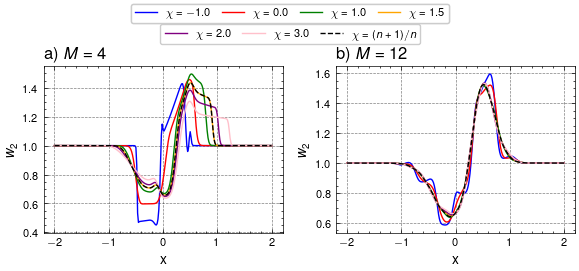

In [16]:
colors = ['blue', 'red', 'green', 'orange', 'purple', 'pink', 'black']
marker = ['o', 'x', 'p', '^', '<', 'v']
linestyles = 6 * ['solid'] + ['dashed']

fig, axs = plt.subplots(1, 2)
Moments_plotting = [4, 12]
for plot_index, M in enumerate(Moments_plotting):
    for i, chi in enumerate(chi_vector):
        filename = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chi{chi}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'

        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, w, t = sol["x"], sol["u"], sol["t"]

        label = f"$\\chi={chi}$"
        if chi == "optimal":
            label = f"$\\chi=(n+1)/n={1+2/M:.3f}$"
        axs[plot_index].plot(x, w[:,2], color=colors[i], linestyle=linestyles[i], label=label)

    axs[plot_index].set_xlabel("x")
    axs[plot_index].set_ylabel("$w_2$")
    axs[plot_index].set_title(f'{labels[plot_index]}) $M={M}$', loc='left')

chi_elements = [Line2D([0], [0], color=colors[i], label=f'$\\chi={chi}$') for i, chi in enumerate(chi_vector[:-1])]
chi_elements.append(Line2D([0], [0], color=colors[-1], label=f'$\\chi=(n+1)/n$', linestyle='--'))
leg1 = fig.legend(
    handles=chi_elements[:4], 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.13), 
    ncol=4, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)
leg2 = fig.legend(
    handles=chi_elements[4:], 
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05), 
    ncol=3, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)
fig.add_artist(leg1)

fig.tight_layout()
fig.savefig('../out/Figures/GaugeInvestigation/GaugeInvestigation.pdf', bbox_inches='tight')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_76246/978194753.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_L2.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_76246/978194753.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_L1.show()


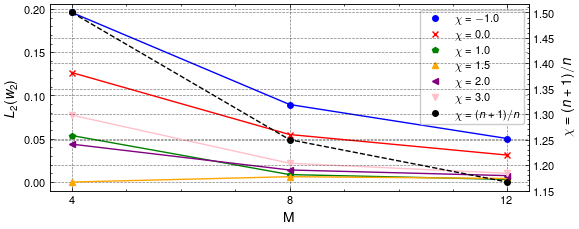

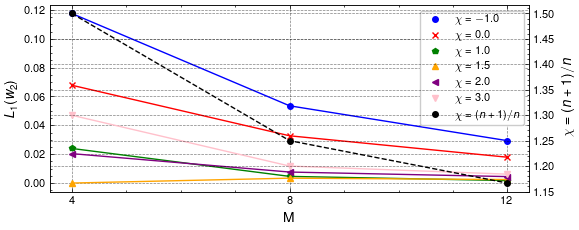

In [17]:
fig_L2, axs_L2 = plt.subplots()
fig_L1, axs_L1 = plt.subplots()
for i, chi in enumerate(chi_vector[:-1]):   # skip optimal, as this is our reference solution
    L2_error = []
    L1_error = []
    for j, M in enumerate(Moments):
        filename = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chi{chi}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'

        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, w, t = sol["x"], sol["u"], sol["t"]

        # Load optimal solution
        filename_optimal = f'../out/Riemann1D/GaugeInvestigation/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_chioptimal_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv'
        data_optimal = read_solution_file(filename_optimal)
        sol_optimal = interpolate_solution(data_optimal, time_query, times, timesteps)
        x_optimal, w_optimal, t_optimal = sol_optimal["x"], sol_optimal["u"], sol_optimal["t"]

        # Interpolate optimal solution onto current grid
        w_opt_interp = np.interp(x, x_optimal, w_optimal[:,2])

        # Compute L2 error
        error_L2 = np.linalg.norm(w[:,2] - w_opt_interp, 2) / np.linalg.norm(w_opt_interp, 2)
        L2_error.append(error_L2)
        # Compute L1 error
        error_L1 = np.linalg.norm(w[:,2] - w_opt_interp, 1) / np.linalg.norm(w_opt_interp, 1)
        L1_error.append(error_L1)

    axs_L2.plot(Moments, L2_error, marker=marker[i], color=colors[i], label=f"$\\chi={chi}$")
    axs_L1.plot(Moments, L1_error, marker=marker[i], color=colors[i], label=f"$\\chi={chi}$")
[axs.set_xlabel("M") for axs in [axs_L1, axs_L2]]
[axs.set_xticks(Moments) for axs in [axs_L1, axs_L2]]
axs_L2.set_ylabel("$L_2(w_2)$")
axs_L1.set_ylabel("$L_1(w_2)$")

chi_optimal = 1 + 2 / np.array(Moments)
twinx = [axs.twinx() for axs in [axs_L1, axs_L2]]
[twinx_.set_ylabel("$\\chi=(n+1)/n$") for twinx_ in twinx] 
[twinx_.plot(Moments, chi_optimal, 'k--', marker='o') for twinx_ in twinx]
[axs.plot([], [], 'k--', label="$\\chi=(n+1)/n$") for axs in [axs_L1, axs_L2]]

chi_elements = [Line2D([0], [0], color=colors[i], marker=marker[i], label=f'$\\chi={chi}$', linestyle='') for i, chi in enumerate(chi_vector[:-1])]
chi_elements.append(Line2D([0], [0], color='k', linestyle='', marker='o', label="$\\chi=(n+1)/n$"))
[axs.legend(handles=chi_elements) for axs in [axs_L1, axs_L2]]

fig_L2.tight_layout()
fig_L2.savefig('../out/Figures/GaugeInvestigation/GaugeInvestigation_L2Error_vs_M.pdf')
fig_L2.show()

fig_L1.tight_layout()
fig_L1.savefig('../out/Figures/GaugeInvestigation/GaugeInvestigation_L1Error_vs_M.pdf')
fig_L1.show()